In [13]:
import gymnasium as gym
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
import pandas as pd
import seaborn as sns

monte carlo gradient descent linear function approximation

In [ ]:
EPISODES = 50000
GAMMA = 1.0
ALPHA = 0.1

env = gym.make("Blackjack-v1", sab=False)

eps_greedy = lambda q_vals, eps: np.random.randint(len(q_vals)) if np.random.rand() < eps else np.argmax(q_vals)
def state_to_idx(s): return s[0]-1, s[1]-1, s[2]
x = lambda s1, s2, s3: np.array([1, s1, s2, s3, s1*s2, s1*s3])
policy = lambda s1, s2, s3: (0 if ((2 <= s2+1 <= 6 and s3 == 0 and s1+1 >= 11) or ( (s2+1 >= 7 or s2+1 == 1) and s3 == 0 and s1+1 >= 16 )) else 1 ) 
#dealer 2-6: Stand hard 12+, dealer strong stand hard 17+; otherwise hit

#init w
w = np.zeros(6) #1, playersum, dealersum, ace, sumxdealer, sumxace

wins = []

#for episode in episodes
for episode in range(EPISODES):
    s, _ = env.reset()
    r_ls = []
    s_ls = []

    while True:
        s1, s2, s3 = state_to_idx(s)
        s_ls.append((s1, s2, s3))
        a = policy(s1, s2, s3)

        s, r, term, trunc, _ = env.step(a)
        r_ls.append(r)

        if term or trunc:
            wins.append(r > 0)
            break

    g = 0
    for i in range(len(r_ls) - 1, -1, -1):
        g = r_ls[i] + GAMMA * g
        xi = x(*s_ls[i])
        w += ALPHA * (g - w @ xi) * xi



env.close()

array([nan, nan, nan, nan, nan, nan])

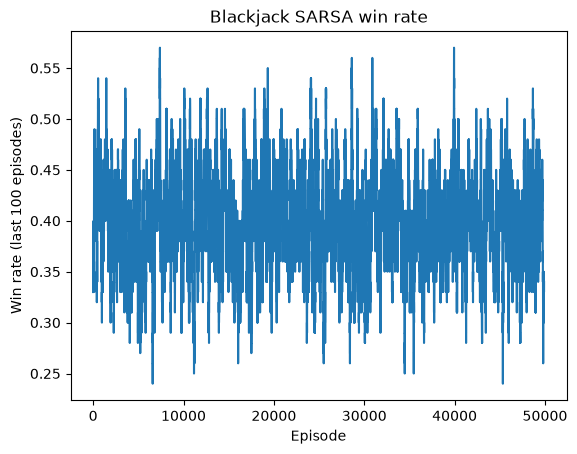

In [15]:
window = 100
win_rate = np.convolve(wins, np.ones(window) / window, mode='valid')

plt.plot(win_rate)
plt.xlabel('Episode')
plt.ylabel(f'Win rate (last {window} episodes)')
plt.title('Blackjack SARSA win rate')
plt.show()

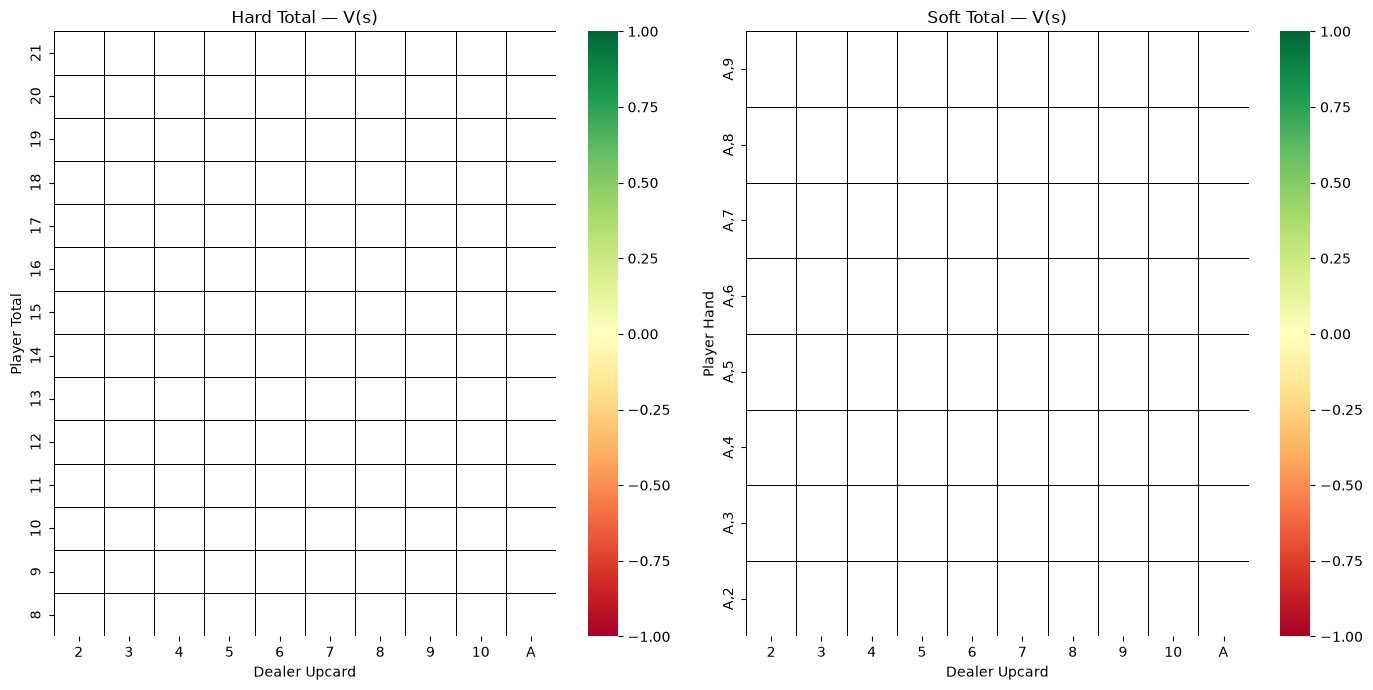

In [16]:
dealer_upcards = [(i, str(i)) for i in range(2, 11)] + [(1, 'A')]

def v_hat(player_sum, dealer_up, usable_ace):
    s1, s2, s3 = player_sum - 1, dealer_up - 1, usable_ace
    return w @ x(s1, s2, s3)

hard_table = []
soft_table = []

for player_sum in range(8, 22):
    for dealer_up, dealer_label in dealer_upcards:
        hard_table.append({
            'Player': player_sum,
            'Dealer': dealer_label,
            'Value': v_hat(player_sum, dealer_up, 0),
        })

for player_sum in range(13, 21):
    hand = f"A,{player_sum - 11}"
    for dealer_up, dealer_label in dealer_upcards:
        soft_table.append({
            'Player': hand,
            'Dealer': dealer_label,
            'Value': v_hat(player_sum, dealer_up, 1),
        })

col_order = [str(i) for i in range(2, 11)] + ['A']
soft_hand_order = [f"A,{i}" for i in range(9, 1, -1)]
hard_pivot = pd.DataFrame(hard_table).pivot(index='Player', columns='Dealer', values='Value')[col_order].sort_index(ascending=False)
soft_pivot = pd.DataFrame(soft_table).pivot(index='Player', columns='Dealer', values='Value')[col_order].reindex(soft_hand_order)

plt.figure(figsize=(14, 7))
plt.subplot(1, 2, 1)
sns.heatmap(hard_pivot, cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=.5, linecolor='black', annot=True, fmt='.2f')
plt.title('Hard Total — V(s)')
plt.xlabel('Dealer Upcard')
plt.ylabel('Player Total')

plt.subplot(1, 2, 2)
sns.heatmap(soft_pivot, cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=.5, linecolor='black', annot=True, fmt='.2f')
plt.title('Soft Total — V(s)')
plt.xlabel('Dealer Upcard')
plt.ylabel('Player Hand')

plt.tight_layout()
plt.show()